In [26]:
library(tidyverse)

In [34]:
# Read in data to large dataframe to set up plots

Lineage = c('Immune', 'Epithelial', 'Stromal', 'Neurons')

Differentia = c('Lymphoid', 'Myeloid', 'Transiently Amplifying Cells (TA)',
       'Colonocytes', 'Secretory', 'Epithelial Stem Cells (LGR5+)',
       'Fibroblasts', 'Pericytes', 'Glia', 'Enteroendocrine Cells (EEC)',
       'Endothelial', 'Enterocytes', 'Smooth Muscle Cells (SMC)',
       'Follicle associated enterocyte (FAE)')

names(Differentia)=Differentia
names(Lineage)=Lineage

base_path <- '~/Projects/GCA/PVCA/'

# Read type data with purrr
diffDF <- Differentia %>%
    map_df(~ {
        data <- read_csv(file.path(base_path, paste0(.x, '_OLS_pvca_per_covariate_robust.csv')))
    }, .id = "Differentia")

# Read lineage data with purrr
lineageDF <- Lineage %>%
            map_df(~ read_csv(file.path(base_path, paste0(.x, '_OLS_pvca_per_covariate_robust.csv'))), .id = "Lineage")



New names:
• `` -> `...1`
Rows: 12 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): covariate
dbl (2): ...1, mean_variance_explained

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 12 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): covariate
dbl (2): ...1, mean_variance_explained

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 12 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): covariate
dbl (2): ...1, mean_variance_explained

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the col

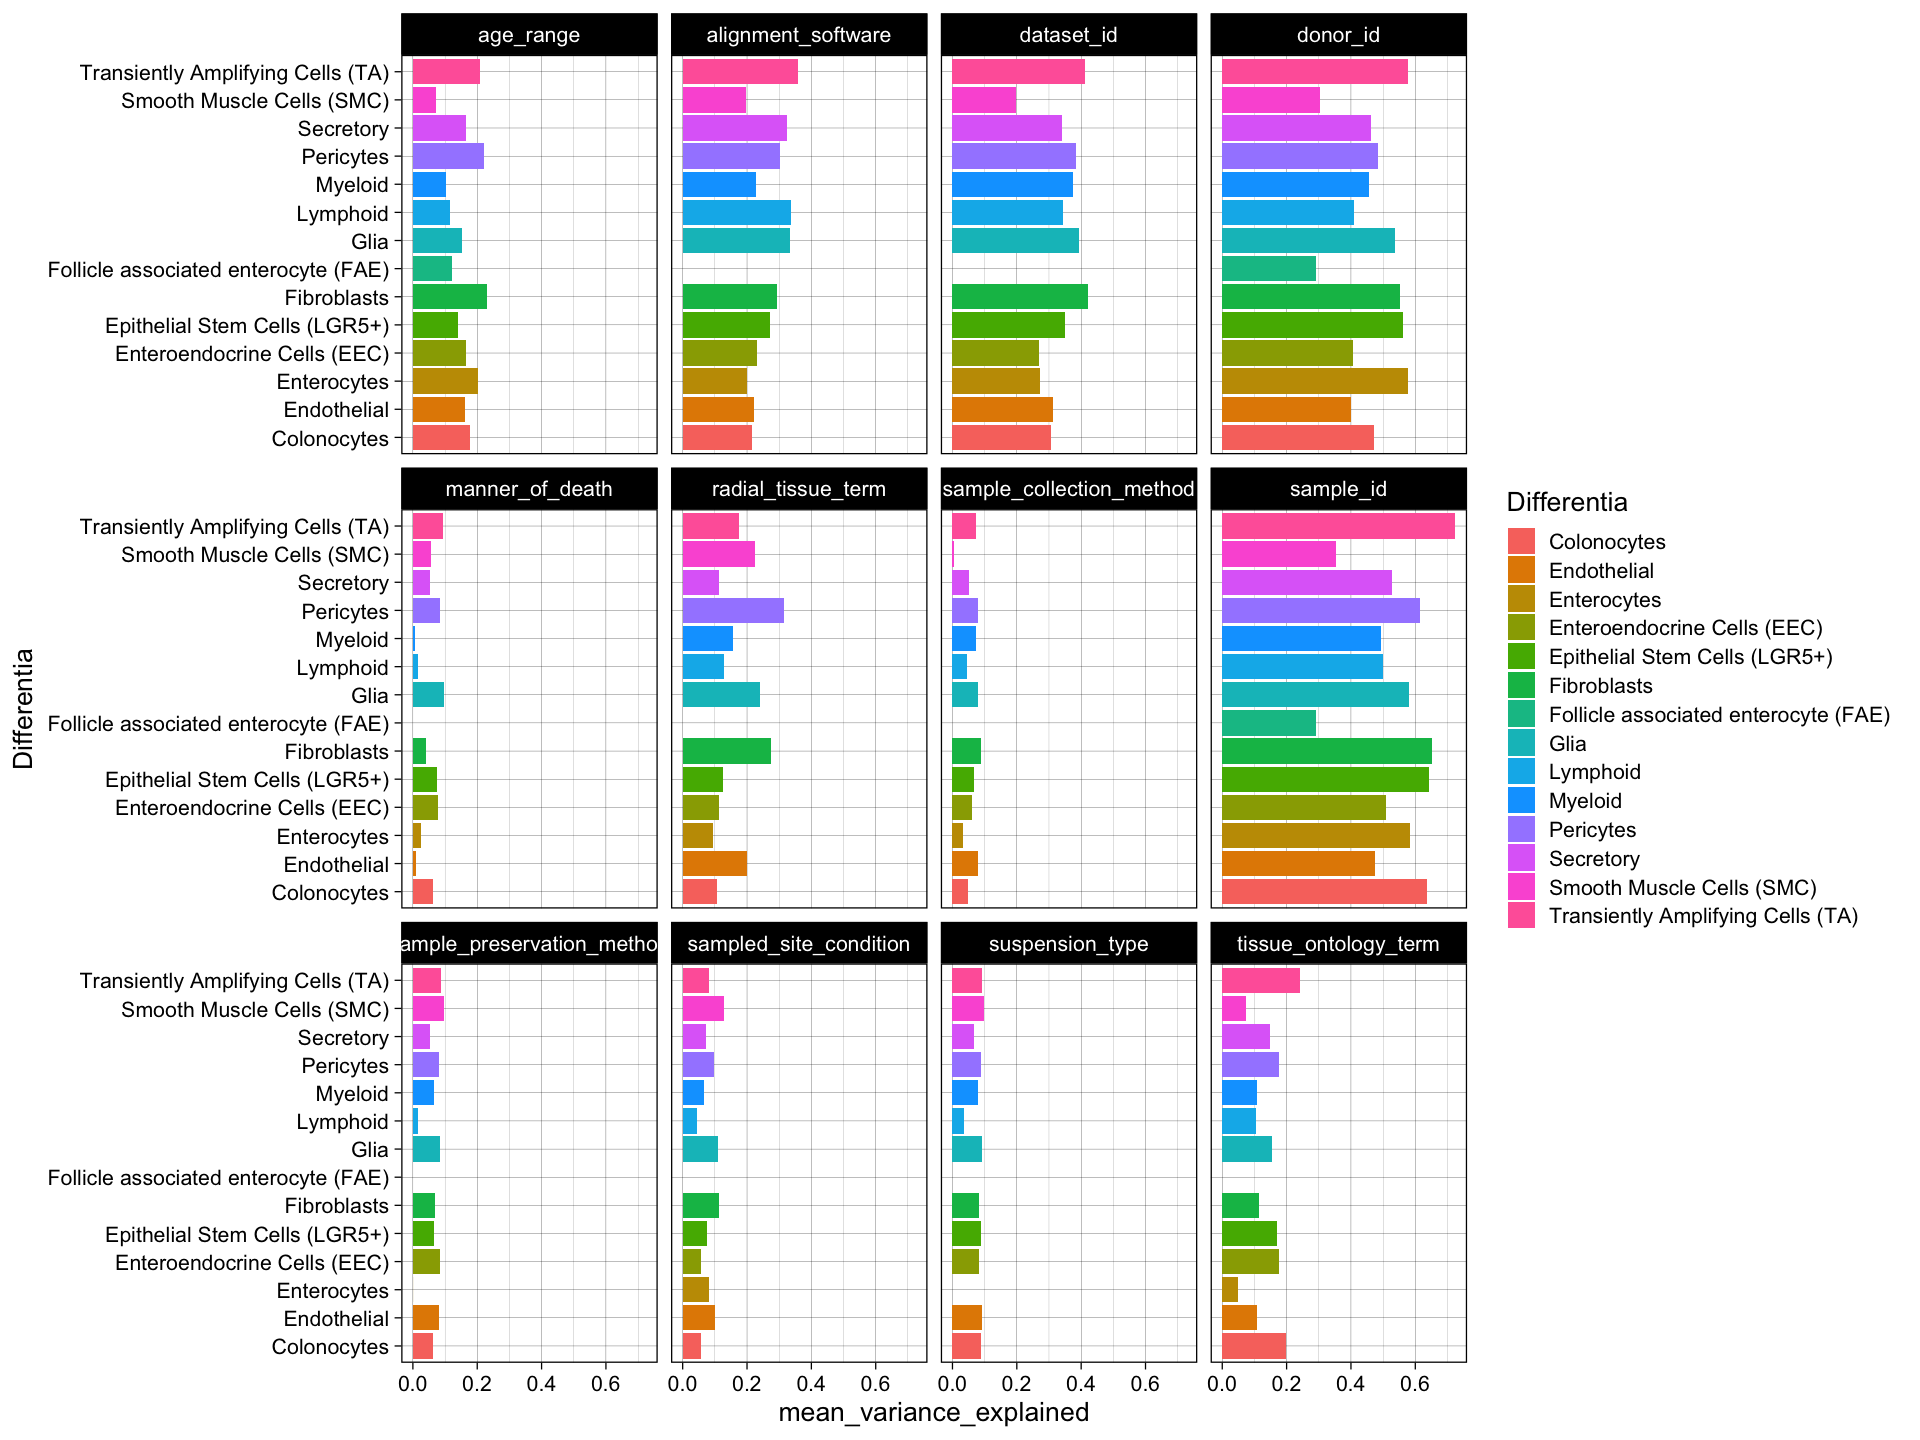

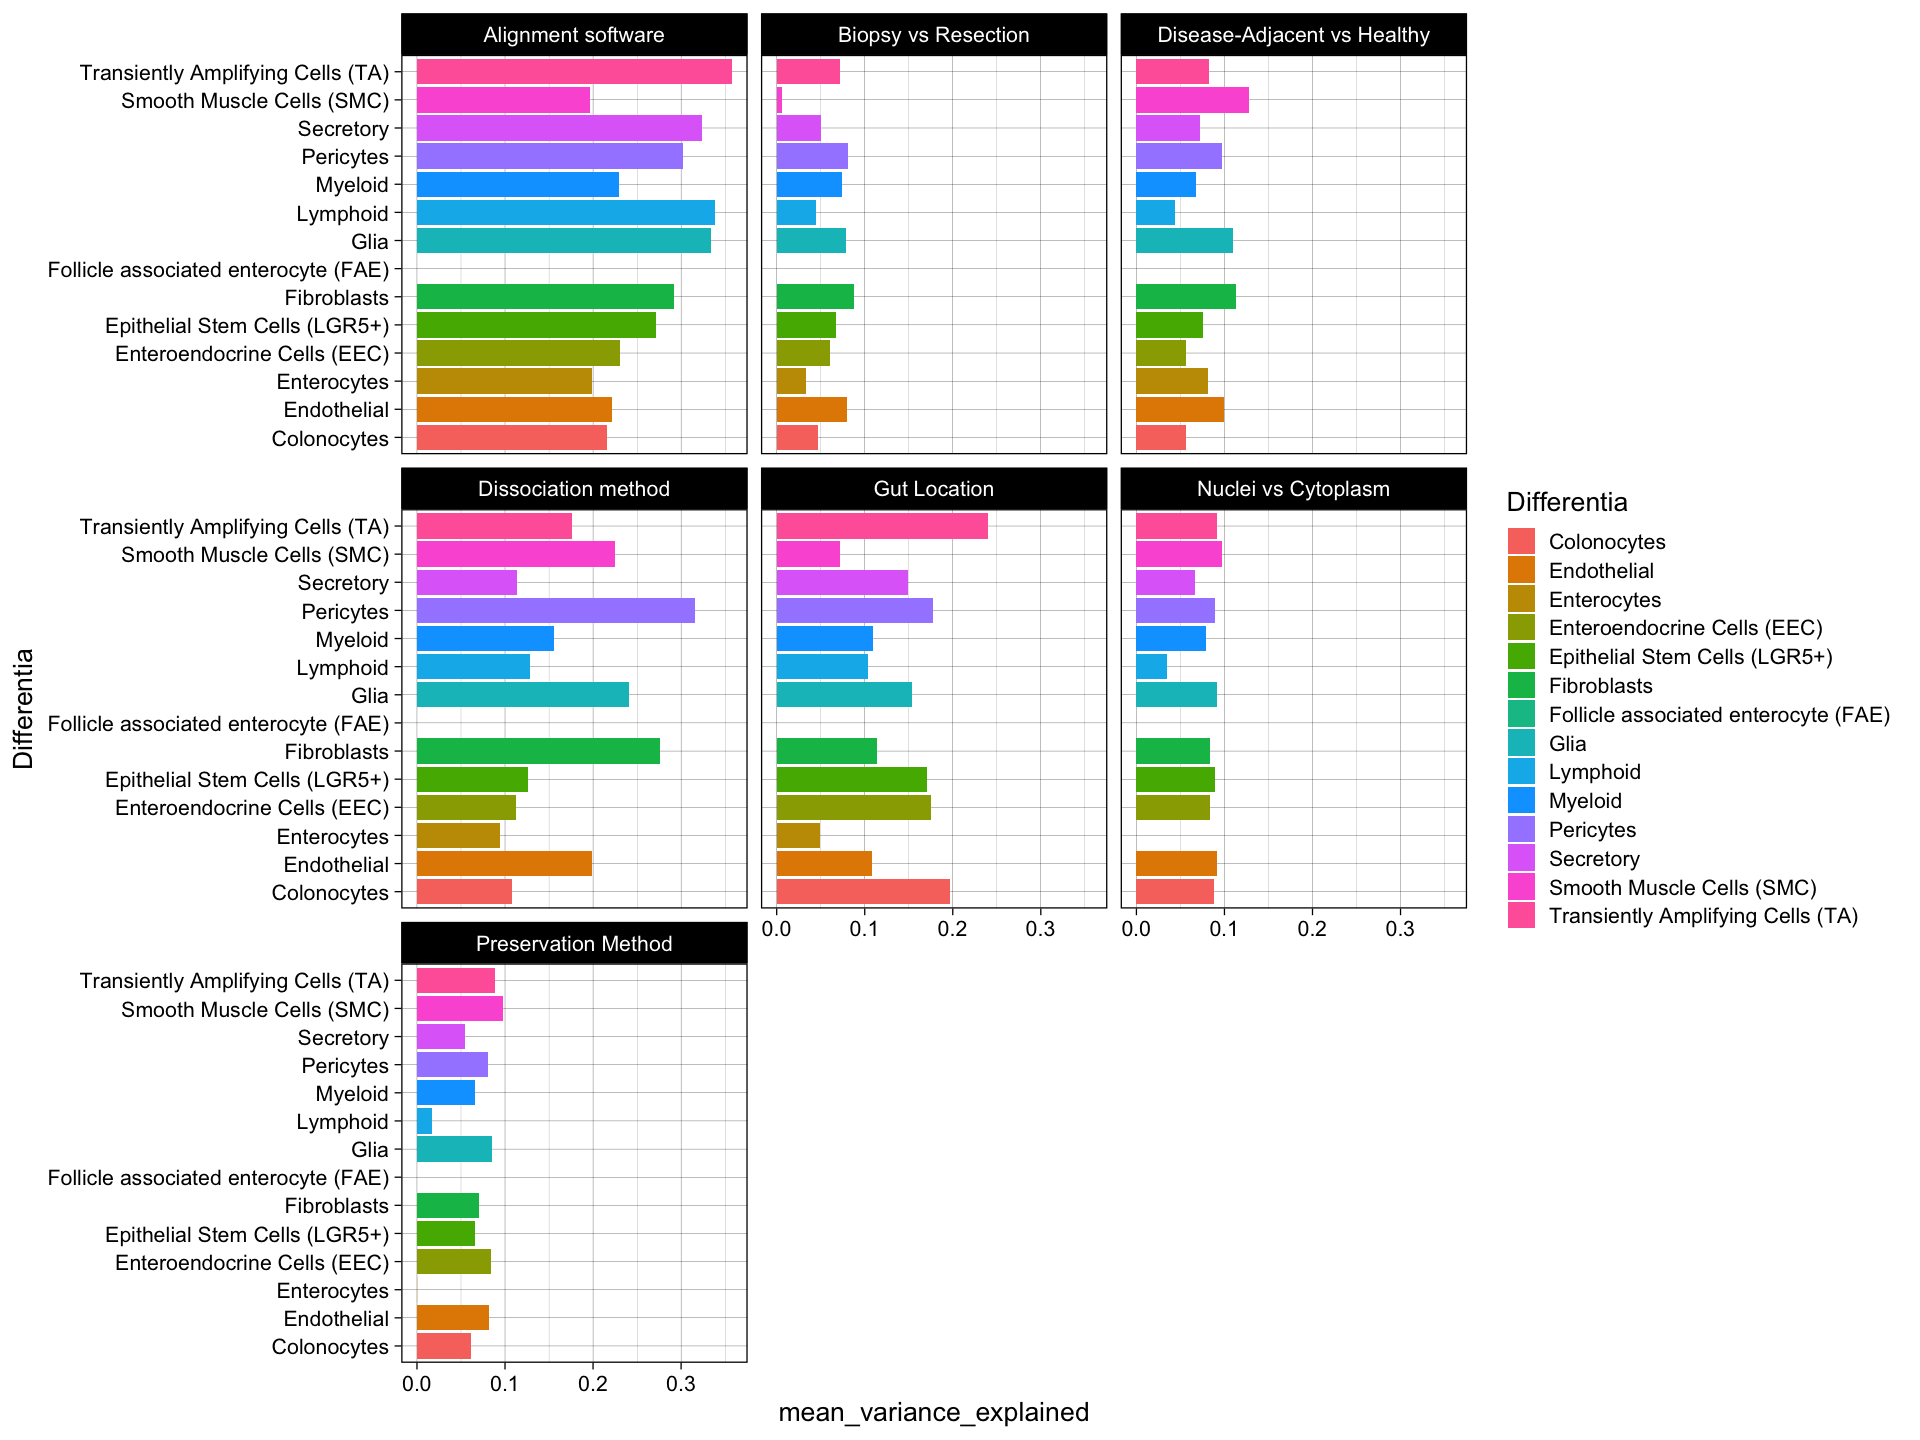

In [35]:
options(repr.plot.width=16, repr.plot.height = 12)

diffDF %>% ggplot(aes(x=Differentia, y=mean_variance_explained, fill = Differentia)) + 
            geom_col() +
            facet_wrap(.~covariate) +
            theme_linedraw(base_size = 16) +
            coord_flip() 

# For presentation
covars = c('alignment_software', 'radial_tissue_term', 'sample_collection_method', 
           'sample_preservation_method', 'sampled_site_condition', 'tissue_ontology_term',
          'suspension_type')

diffDF <- diffDF %>% filter(covariate %in% covars) %>%
    mutate(covariate = case_when(
        covariate=="alignment_software" ~ "Alignment software",
        covariate=="radial_tissue_term" ~ "Dissociation method",
        covariate=="sample_collection_method" ~ "Biopsy vs Resection",
        covariate=="sample_preservation_method" ~ "Preservation Method",
        covariate=="sampled_site_condition" ~ "Disease-Adjacent vs Healthy",
        covariate=="tissue_ontology_term" ~ "Gut Location",
        covariate=="suspension_type" ~ "Nuclei vs Cytoplasm",
        TRUE ~ covariate))

diffDF %>% ggplot(aes(x=Differentia, y=mean_variance_explained, fill = Differentia)) + 
            geom_col() +
            facet_wrap(.~covariate) +
            theme_linedraw(base_size = 16) +
            coord_flip() 


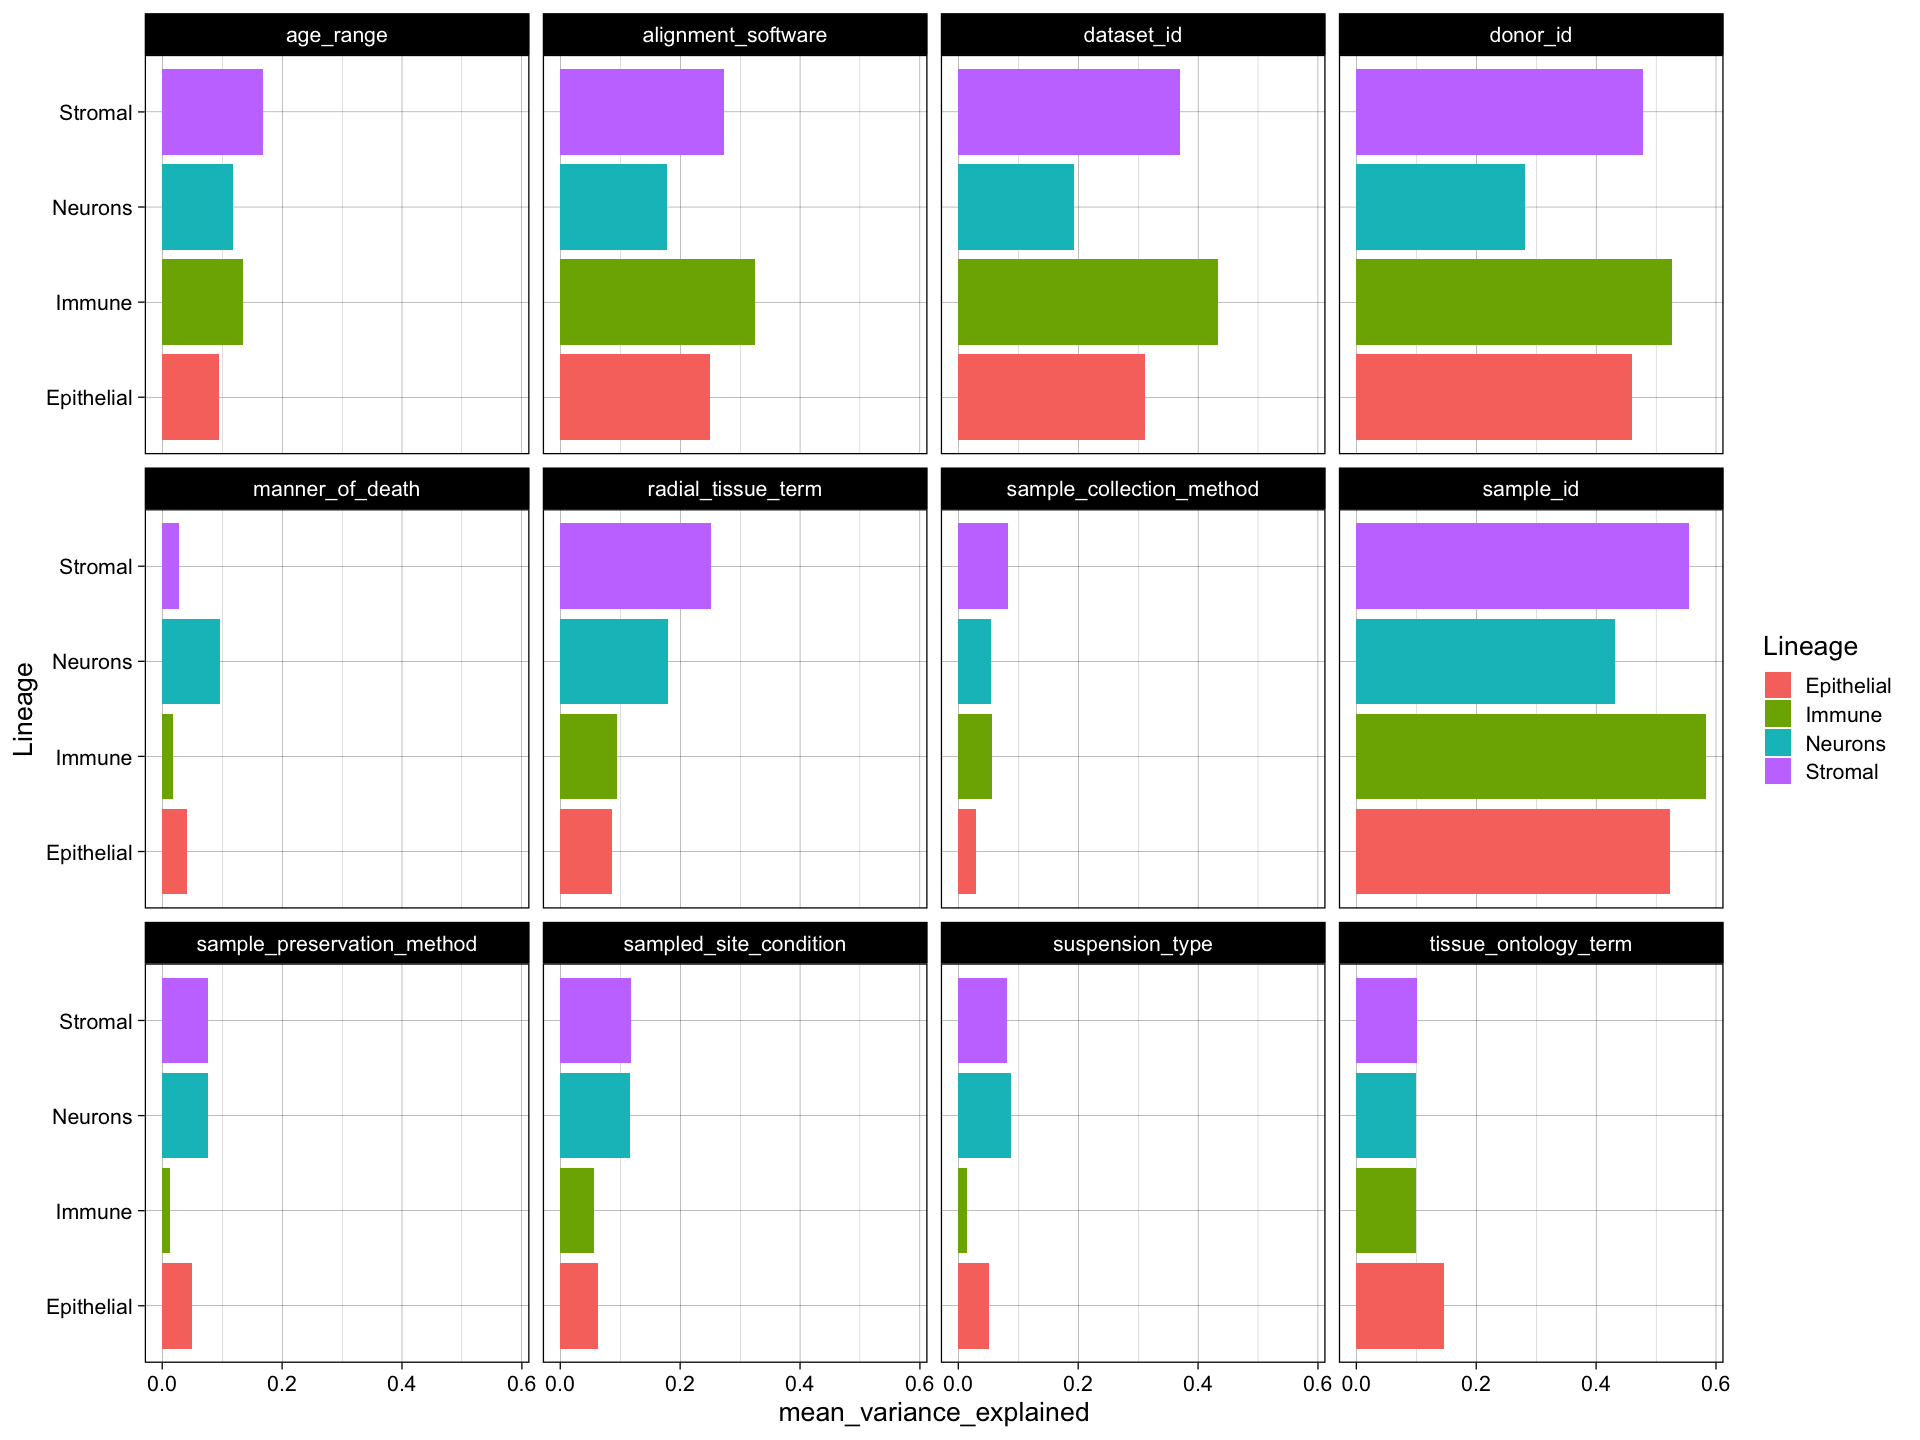

In [36]:
options(repr.plot.width=16, repr.plot.height = 12)

lineageDF %>% ggplot(aes(x=Lineage, y=mean_variance_explained, fill = Lineage)) + 
            geom_col() +
            facet_wrap(.~covariate) +
            theme_linedraw(base_size = 16) +
            coord_flip() 
            
lineageDF <- lineageDF %>% filter(covariate %in% covars) %>%
    mutate(covariate = case_when(
        covariate=="alignment_software" ~ "Alignment software",
        covariate=="radial_tissue_term" ~ "Dissociation method",
        covariate=="sample_collection_method" ~ "Biopsy vs Resection",
        covariate=="sample_preservation_method" ~ "Preservation Method",
        covariate=="sampled_site_condition" ~ "Disease-Adjacent vs Healthy",
        covariate=="tissue_ontology_term" ~ "Gut Location",
        covariate=="suspension_type" ~ "Nuclei vs Cytoplasm",
        TRUE ~ covariate))



In [37]:
lineageDF

Lineage,...1,covariate,mean_variance_explained
<chr>,<dbl>,<chr>,<dbl>
Immune,1,Alignment software,0.32411163
Immune,11,Gut Location,0.09977010
Immune,5,Dissociation method,0.09542456
Immune,9,Disease-Adjacent vs Healthy,0.05631125
Immune,6,Biopsy vs Resection,0.05596622
Immune,10,Nuclei vs Cytoplasm,0.01515043
Immune,8,Preservation Method,0.01236374
Epithelial,1,Alignment software,0.24955777
Epithelial,11,Gut Location,0.14669717


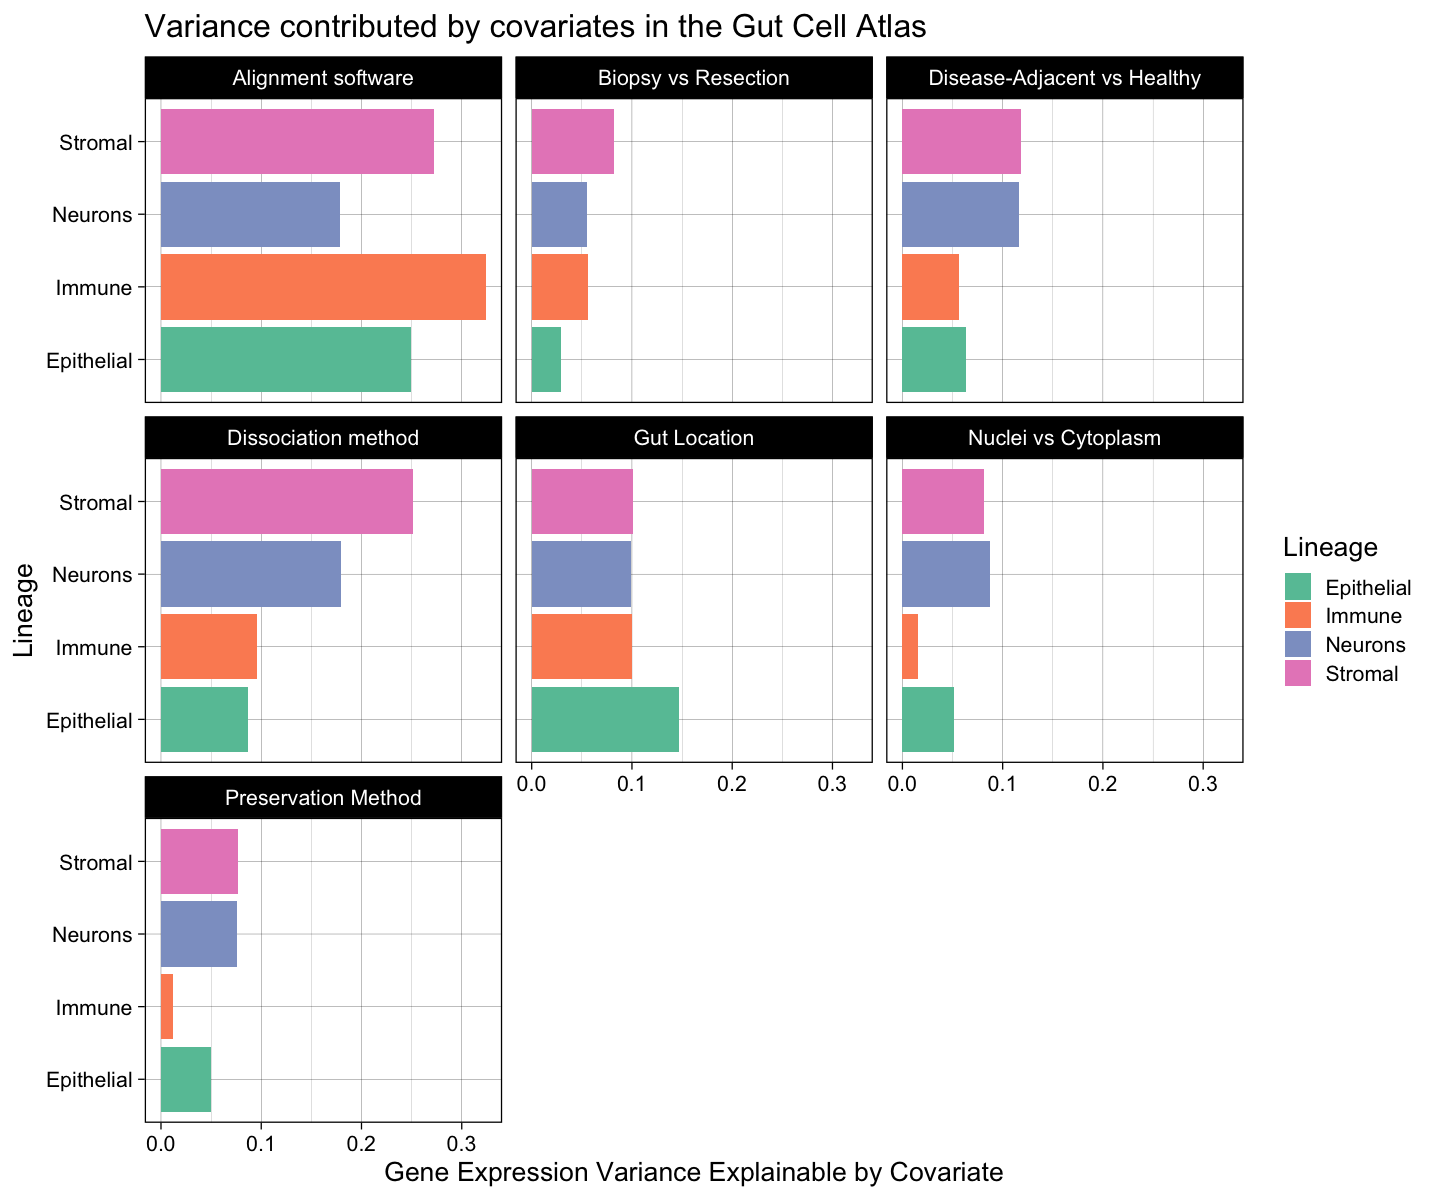

In [46]:
options(repr.plot.width = 12, repr.plot.height=10)
plt <- lineageDF %>% ggplot(aes(x=Lineage, y=mean_variance_explained, fill = Lineage)) + 
            geom_col() +
            facet_wrap(.~covariate) +
            theme_linedraw(base_size = 16) +
            coord_flip() +
            ylab('Gene Expression Variance Explainable by Covariate') +
            ggtitle("Variance contributed by covariates in the Gut Cell Atlas") +
            scale_fill_brewer(palette='Set2')

plt

ggsave('~/Projects/GCA/PVCA/Lineage_Select_Covariates_Bargraphs.png', width = 12, height = 10, plot = plt)